# 13 · From a source to a defensible map story

[Run this lesson in Python Lab](https://jltobias.github.io/JupyterLite-Climate-and-Health/lite/lab/index.html?path=notebooks/13_evidence_atlas.ipynb) · [Open the Evidence Atlas](https://jltobias.github.io/JupyterLite-Climate-and-Health/stac/)

**Audience:** public-health students and practitioners. **Time:** 45–60 minutes.

Audit actual packaged satellite metadata, mapped reef habitats, archived facility locations and citizen-science observations. Learn to preserve the denominator, acquisition period, geographic support and license. Nothing in this lesson estimates a patient's disease risk.

The small local files work in JupyterLite. No account, secret key or global raster download is required.

In [1]:
from pathlib import Path
import json, csv, hashlib
from collections import Counter
from statistics import mean
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path('../data') if Path('../data').is_dir() else Path('data')
def read_json(name):
    return json.loads((DATA / name).read_text(encoding='utf-8'))

snapshots = {name: read_json('stac_' + name + '.json')
             for name in ['copernicus_mumbai', 'dea_beira', 'allen_mombasa']}
audit = [{'sample': name, 'records': len(doc['feature_collection']['features']),
          'class': doc['provenance']['data_class'],
          'retrieved': doc['provenance']['retrieved_on'],
          'rights': doc['provenance']['license']}
         for name, doc in snapshots.items()]
display(pd.DataFrame(audit))

,sample,records,class,retrieved,rights
0,copernicus_mumbai,6,catalog_metadata_snapshot,2026-10-09,Copernicus Sentinel data legal notice; collect...
1,dea_beira,4,catalog_metadata_snapshot,2026-10-09,CC-BY-4.0
2,allen_mombasa,8,habitat_classification_subset,2026-10-09,CC-BY-4.0


## Read the time and the footprint

The date when this repository retrieved metadata is distinct from the satellite acquisition date and processing time. A DEA annual item covers an interval. A STAC geometry is a scene footprint, not a flood boundary. Missing cloud cover stays missing.

In [2]:
rows = []
for name in ['copernicus_mumbai', 'dea_beira']:
    for item in snapshots[name]['feature_collection']['features']:
        p = item['properties']
        rows.append({'sample': name, 'id': item['id'],
                     'start': p.get('start_datetime', p.get('datetime')),
                     'end': p.get('end_datetime', p.get('datetime')),
                     'cloud_percent': p.get('eo:cloud_cover'),
                     'assets': len(item.get('assets', {}))})
display(pd.DataFrame(rows))
print('Cloud values absent:', sum(r['cloud_percent'] is None for r in rows))
print('No imagery pixels have been downloaded or analyzed.')

,sample,id,start,end,cloud_percent,assets
0,copernicus_mumbai,S2B_MSIL2A_20240428T052649_N0510_R105_T43QCB_2...,2024-04-28T05:26:49.024000Z,2024-04-28T05:26:49.024000Z,0.04,47
1,copernicus_mumbai,S2B_MSIL2A_20240428T052649_N0510_R105_T43QCA_2...,2024-04-28T05:26:49.024000Z,2024-04-28T05:26:49.024000Z,0.00,47
2,copernicus_mumbai,S2B_MSIL2A_20240428T052649_N0510_R105_T43QBA_2...,2024-04-28T05:26:49.024000Z,2024-04-28T05:26:49.024000Z,0.36,47
3,copernicus_mumbai,S2A_MSIL2A_20240426T053641_N0510_R005_T43QCB_2...,2024-04-26T05:36:41.024000Z,2024-04-26T05:36:41.024000Z,6.06,47
4,copernicus_mumbai,S2A_MSIL2A_20240426T053641_N0510_R005_T43QCA_2...,2024-04-26T05:36:41.024000Z,2024-04-26T05:36:41.024000Z,0.00,47
5,copernicus_mumbai,S2A_MSIL2A_20240426T053641_N0510_R005_T43QBB_2...,2024-04-26T05:36:41.024000Z,2024-04-26T05:36:41.024000Z,9.81,47
6,dea_beira,29303217-b837-5efb-af87-a4225533ec6c,2022-01-01T00:00:00Z,2022-12-31T23:59:59.999999Z,NaN,3
7,dea_beira,a135ef22-2d14-551a-8d7c-d4afa789fd01,2022-01-01T00:00:00Z,2022-12-31T23:59:59.999999Z,NaN,3
8,dea_beira,c1d182b7-bb1c-5355-b0ad-b23c7d0dc859,2022-01-01T00:00:00Z,2022-12-31T23:59:59.999999Z,NaN,3
9,dea_beira,e6182822-a2ab-571b-b4fa-53ecaefae177,2022-01-01T00:00:00Z,2022-12-31T23:59:59.999999Z,NaN,3


Cloud values absent: 4
No imagery pixels have been downloaded or analyzed.


## Map a real habitat extract in two dimensions

Allen Coral Atlas provides mapped benthic habitat. The eight polygons below came from one bounded WFS request near Mombasa. They are the first returned features, not a representative sample. Areas and classes are provider attributes; this exercise does not recompute area in longitude/latitude degrees.

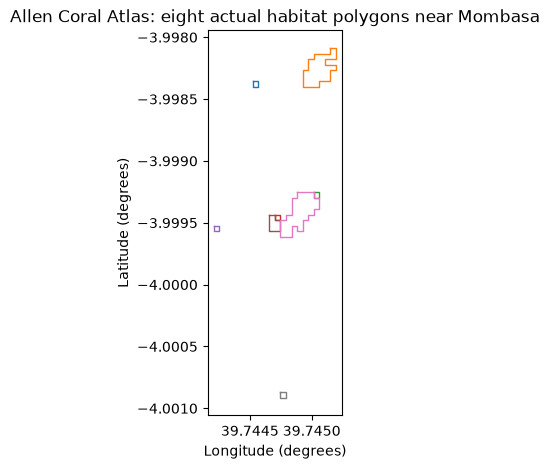

,class_name,area_sqkm
0,Seagrass,0.000025
1,Sand,0.000644
2,Seagrass,0.000025
3,Coral/Algae,0.000025
4,Seagrass,0.000025
5,Seagrass,0.000124
6,Sand,0.000743
7,Seagrass,0.000025


Allen Coral Atlas Partnership / Arizona State University; CC BY 4.0; doi:10.5281/zenodo.3833242


In [3]:
habitats = snapshots['allen_mombasa']['feature_collection']['features']
fig, ax = plt.subplots(figsize=(7, 5))
for feature in habitats:
    geometry = feature['geometry']
    polygons = [geometry['coordinates']] if geometry['type'] == 'Polygon' else geometry['coordinates']
    for polygon in polygons:
        ring = polygon[0]  # Outer ring only: this display is not an area calculation.
        ax.plot([xy[0] for xy in ring], [xy[1] for xy in ring], linewidth=1)
ax.set(xlabel='Longitude (degrees)', ylabel='Latitude (degrees)',
       title='Allen Coral Atlas: eight actual habitat polygons near Mombasa')
ax.set_aspect('equal'); ax.ticklabel_format(useOffset=False)
plt.show()
display(pd.DataFrame([f['properties'] for f in habitats]))
print('Allen Coral Atlas Partnership / Arizona State University; CC BY 4.0; doi:10.5281/zenodo.3833242')

## Compare field observations without conflating indicators

The CoralWatch sample is from **Egypt**, not the Mombasa polygons above. It demonstrates a different type of evidence and must not be joined as if the locations or dates matched. Each lightest/darkest pair describes one sampled coral. Colour scores are not percent bleaching, reef-wide cover or NOAA Degree Heating Weeks.

In [4]:
coral_meta = read_json('coralwatch_random_survey_20.metadata.json')
coral_path = DATA / coral_meta['csv_file']
assert hashlib.sha256(coral_path.read_bytes()).hexdigest() == coral_meta['csv_sha256']
corals = pd.read_csv(coral_path)
assert ((corals.lightest_colour_score + corals.darkest_colour_score) / 2 == corals.average_colour_score).all()
print(coral_meta['reef_context'])
print('Published eventDate:', coral_meta['event_datetime_source'])
print('Submitted corals:', len(corals))
print('Descriptive mean of chart scores:', round(mean(corals.average_colour_score), 3))
print(coral_meta['citation'])
display(corals.groupby('coral_form').average_colour_score.agg(['count', 'mean']))

Abu Sawatyr, Red Sea, Egypt
Published eventDate: 2026-10-08T21:00:00Z
Submitted corals: 20
Descriptive mean of chart scores: 2.875
CoralWatch (2026). CoralWatch Random Survey dataset, survey bd39e449-038f-4d45-ab6d-b56922a6f532, Abu Sawatyr, Egypt; 20-observation reduced extract. https://biocollect.ala.org.au/coralwatch/bioActivity/index/bd39e449-038f-4d45-ab6d-b56922a6f532 (accessed 2026-10-09). CC BY 4.0. Changes: numeric scores extracted from chart codes; personal fields, exact coordinates, and photographs omitted.


,count,mean
coral_form,,
Boulder corals,5,3.000000
Branching corals,10,2.700000
Plate corals,3,3.333333
Soft corals,2,2.750000


## Check facility coverage and source rights

The archived Healthsites extract includes India and six African teaching contexts. Counts reflect the selection procedure, not country totals or a measure of health-system capacity. No facility is assigned a synthetic hazard score or presumed PEPFAR service status.

In [5]:
facilities = read_json('healthsites_facilities.geojson')['features']
assert len({f['properties']['osm_id'] for f in facilities}) == len(facilities)
display(pd.DataFrame(sorted(Counter(f['properties']['context_city'] for f in facilities).items()),
                     columns=['Selected context', 'Archived point features']))
registry = read_json('source-registry.json')
theme = 'Disease'  # Try Water, Reefs, Equity, Adaptation or Earth observation.
display(pd.DataFrame([{'source': s['title'], 'access': s['access'], 'rights': s['license']}
                      for s in registry['sources'] if theme in s['themes']]))

,Selected context,Archived point features
0,Beira,11
1,Durban,24
2,Kampala,24
3,Lagos,24
4,Lusaka,24
5,Mombasa,24
6,Mumbai,24


,source,access,rights
0,The GDELT Project,"Public bulk metadata, BigQuery and documented ...",GDELT's own terms permit dataset reuse and red...
1,"IPCC AR6: Impacts, Adaptation and Vulnerability",Public report and chapter downloads; use offic...,IPCC/Cambridge publication rights and figure c...
2,Surgo Africa COVID-19 Community Vulnerability ...,Public dashboard and archived Zenodo dataset; ...,Archived dataset: CC BY-NC 4.0; dashboard cont...
3,WHO / WMO Atlas of Health and Climate,"WHO, TDR and WMO landing pages point to the sa...","Current WHO page states CC BY-NC-SA 3.0 IGO, w..."
4,Malaria Atlas Project,Public platform and documented HTTP access gui...,MAP maps explicitly CC BY 3.0; original survey...
5,EAACI Global Atlas of Planetary Health,Public 2025 atlas PDF; v1.2 appears in the sup...,No blanket open license verified; figure-speci...
6,ClimaHealth / Wellcome Climate Change Impact Map,Public interactive dashboard. No underlying CR...,Wellcome website default CC BY 4.0 does not ov...


## Your exercise

1. Change `theme` to a topic relevant to your practice. Choose one source and write the health question it can help contextualize.
2. Use the Evidence Atlas to load one packaged example, inspect an item and export its metadata. Then try a bounded live query. Record whether it succeeded; a failed request does not mean no observations exist.
3. Write a five-stop tour: place, observed evidence, uncertainty, possible response and decision needing local input. Create a source card with product, version, dates, geographic support, units, denominator, missingness and license.
4. Explain why these Egyptian field observations cannot validate a Kenyan habitat polygon, and what a suitable matched field study would require.
5. For a malaria extension, use the MAP gateway to identify one named country summary. Record species, metric, denominator, release, year and uncertainty. Do not call modeled incidence a surveillance count or an effect caused by climate.

## Interpretation

The satellite samples contain scene metadata, not raster measurements. Allen polygons are habitat classifications. CoralWatch contains submitted field colour observations from one survey. Healthsites provides archived map features. Each can support a different question; proximity or shared geography alone cannot establish a causal pathway to health outcomes.

For a disparity story, compare sources that retain population denominators and missingness. Country means hide within-country variation. Separate exposure, susceptibility, service access and adaptive capacity before discussing priorities.

## Source and limitation

Packaged provenance accompanies each source. [Copernicus](https://documentation.dataspace.copernicus.eu/APIs/STAC.html) uses the Sentinel legal notice; [DEA WOfS](https://docs.digitalearthafrica.org/en/latest/data_specs/Landsat_WOfS_specs.html) and the [Allen mapped habitat product](https://allencoralatlas.org/resources/) use CC BY 4.0. The specific [CoralWatch survey](https://biocollect.ala.org.au/coralwatch/bioActivity/index/bd39e449-038f-4d45-ab6d-b56922a6f532) states CC BY 4.0; other survey types differ. Healthsites/OSM is ODbL 1.0. No provider endorsement is implied.

See the [Book evidence library](https://jltobias.github.io/JupyterLite-Climate-and-Health/book/evidence-library/) for MAP, WHO/WMO, EAACI, IOM, FEWS NET, Aqueduct, forests, fisheries and other linked providers. Linking a gateway does not mean its dataset is packaged or its figures may be copied.